# Day 33: Multi-Agent Supervisor

Day 31 built one agent with tools. Today we build a **team** — a supervisor routes tasks to specialist agents.

## Install

In [10]:
%pip install langgraph langchain-google-genai langchain --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Setup

In [17]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.tools import tool

load_dotenv(dotenv_path='../.env')
os.environ["GOOGLE_API_KEY"] = os.environ["GEMINI_API_KEY"]

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
print("\u2705 Model ready")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


✅ Model ready


## Define Specialists

Each specialist is a function with its own system prompt, wrapped as a `@tool`. The supervisor will call these like any other tool.

In [ ]:
@tool
def research_topic(query: str) -> str:
    """Research a topic and return key facts. Use this to gather information before writing."""
    response = model.invoke([
        {"role": "system", "content": "You are a researcher. Return exactly 3 key facts about the topic. One sentence per fact. No intro, no outro."},
        {"role": "user", "content": query}
    ])
    return response.content

@tool
def write_summary(facts: str) -> str:
    """Write a polished summary from research facts. Use this after researching a topic."""
    response = model.invoke([
        {"role": "system", "content": "You are a writer. Turn these facts into a 2-3 sentence summary for a general audience. Be clear and engaging. No bullet points."},
        {"role": "user", "content": facts}
    ])
    return response.content

tools = [research_topic, write_summary]
print("\u2705 Specialists defined: researcher + writer")

✅ Specialists defined: researcher + writer


## Build Supervisor

Same graph pattern as Day 31. But the tools aren't APIs — they're **other agents**.

In [13]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langchain_core.messages import ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

supervisor_model = model.bind_tools(tools)

SUPERVISOR_PROMPT = (
    "You are a supervisor coordinating a researcher and a writer. "
    "For any request: first call research_topic to gather facts, "
    "then call write_summary to turn those facts into polished text. "
    "Always use both tools in sequence."
)

def supervisor_node(state: State):
    messages = [SystemMessage(content=SUPERVISOR_PROMPT)] + state["messages"]
    return {"messages": [supervisor_model.invoke(messages)]}

def tool_node(state: State):
    results = []
    for call in state["messages"][-1].tool_calls:
        fn = {t.name: t for t in tools}[call["name"]]
        output = fn.invoke(call["args"])
        results.append(ToolMessage(content=str(output), tool_call_id=call["id"]))
    return {"messages": results}

def should_continue(state: State) -> Literal["tool_node", "__end__"]:
    return "tool_node" if state["messages"][-1].tool_calls else END

In [18]:
builder = StateGraph(State)
builder.add_node("supervisor", supervisor_node)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "supervisor")
builder.add_conditional_edges("supervisor", should_continue, ["tool_node", END])
builder.add_edge("tool_node", "supervisor")

supervisor_agent = builder.compile()
print("\u2705 Supervisor agent compiled")

✅ Supervisor agent compiled


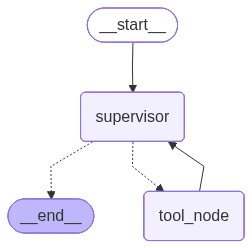

In [19]:
from IPython.display import Image, display

display(Image(supervisor_agent.get_graph().draw_mermaid_png()))

## Test: Multi-Step Task

The supervisor should call the researcher first, then the writer.

In [20]:
result = supervisor_agent.invoke(
    {"messages": [{"role": "user", "content": "Research quantum computing and write a summary for beginners."}]}
)

for msg in result["messages"][:-1]:
    msg.pretty_print()

final = result["messages"][-1]
content = final.content if isinstance(final.content, str) else final.content[0]["text"]
print("================================== Ai Message ==================================\n")
print(content)

================================ Human Message =================================

Research quantum computing and write a summary for beginners.
================================== Ai Message ==================================
Tool Calls:
  research_topic (1fb41d29-fc66-4769-b109-751e233b4366)
 Call ID: 1fb41d29-fc66-4769-b109-751e233b4366
  Args:
    query: quantum computing
================================= Tool Message =================================

Quantum computing harnesses quantum-mechanical phenomena like superposition and entanglement to process information.
This technology holds the potential to solve certain problems intractable for classical computers, particularly in drug discovery, material science, and cryptography.
Current quantum computers are still in early development, facing challenges like decoherence and error correction before widespread practical application.
================================== Ai Message ==================================
Tool Calls:
  write_s

## Test: Research Only

If we just ask for facts, does the supervisor skip the writer?

In [21]:
result = supervisor_agent.invoke(
    {"messages": [{"role": "user", "content": "Give me key facts about black holes."}]}
)

content = result["messages"][-1].content
if isinstance(content, list):
    content = content[0]["text"]
print(content)

Black holes are incredibly dense regions of spacetime where gravity is so powerful that nothing, not even light, can escape their grasp. These cosmic giants typically form from the collapsed remnants of massive stars, creating an invisible boundary known as the event horizon—the ultimate point of no return for anything that crosses it.


## Key Takeaways

1. **Agents can be tools** — wrap a specialist function with `@tool`, and the supervisor calls it like any other tool
2. **Same graph pattern** as Day 31 — `bind_tools`, `should_continue`, `add_conditional_edges` — the only change is what the tools do
3. The **supervisor decides** which agent to call and when — that's coordination, not just routing